<a href="https://colab.research.google.com/github/A01801224/Modulo_3_Bkron/blob/main/Ejercicio_6/Modulo_3_Ejercicio_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering-Ejercicio 6

### Importamos las librerías necesarias para el feature engineering

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

### Definimos la url del dataset y lo imprimimos para comprobar que la información correcta

In [8]:
url = "student_feature_engineering_dataset.csv"

df = pd.read_csv(url)
df.head()

,student_id,age,gender,program,enrollment_year,hours_studied,attendance,previous_grade,current_midterm,sleep_hours,commute_time,num_assignments_late,internet_access,final_grade,passed
0,S001,21,Male,IDM,2022,12.5,73.7,100.0,58.8,8.0,24,0,Yes,67.7,No
1,S002,24,Male,IDM,2025,11.9,88.1,88.7,58.1,8.7,24,2,Yes,68.6,No
2,S003,20,Female,ITC,2024,10.9,72.7,68.8,59.0,8.1,19,0,Yes,69.2,No
3,S004,21,Male,IRS,2022,13.4,93.0,55.6,50.1,6.8,5,2,Yes,72.4,Yes
4,S005,23,Male,IDM,2022,14.6,97.9,78.1,55.2,6.2,30,2,Yes,71.8,Yes


### Exploratory Data Analysis

In [9]:
df.describe()

,age,enrollment_year,hours_studied,attendance,previous_grade,current_midterm,sleep_hours,commute_time,num_assignments_late,final_grade
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,21.683333,2023.383333,10.344167,82.492500,77.862500,50.979167,6.890000,34.508333,1.433333,64.780833
std,2.173110,1.124093,4.010298,8.672318,11.653961,8.959347,1.163983,18.824709,1.281631,9.497902
min,18.000000,2022.000000,2.000000,49.600000,52.700000,35.000000,4.000000,5.000000,0.000000,45.100000
25%,20.000000,2022.000000,7.100000,76.325000,69.250000,44.700000,6.075000,23.250000,0.000000,57.875000
50%,22.000000,2023.000000,10.800000,82.450000,77.500000,50.800000,6.900000,34.000000,1.000000,64.150000
75%,24.000000,2024.000000,12.700000,88.300000,85.825000,57.125000,7.700000,47.000000,2.000000,71.625000
max,25.000000,2025.000000,25.000000,100.000000,100.000000,74.100000,9.900000,86.000000,6.000000,89.400000


Si sabemos que `gender` e `internet_acces` son variables binarias, debemos de comprobar si el número de valores únicos de las variables categóricas con respecto al número de filas es relevante. Por eso, imprimimos los valores únicos de las variables categóricas

In [10]:
df['program'].nunique()

4

In [11]:
df['enrollment_year'].nunique()

4

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            120 non-null    object 
 1   age                   120 non-null    int64  
 2   gender                120 non-null    object 
 3   program               120 non-null    object 
 4   enrollment_year       120 non-null    int64  
 5   hours_studied         120 non-null    float64
 6   attendance            120 non-null    float64
 7   previous_grade        120 non-null    float64
 8   current_midterm       120 non-null    float64
 9   sleep_hours           120 non-null    float64
 10  commute_time          120 non-null    int64  
 11  num_assignments_late  120 non-null    int64  
 12  internet_access       120 non-null    object 
 13  final_grade           120 non-null    float64
 14  passed                120 non-null    object 
dtypes: float64(6), int64(4)

# Feature Analysis

Para esta sección, decidimos transformar las variables categóricas en variables numéricas mediante OneHotEncoder. Esto nos permite representar cada categoría de forma independiente y, posteriormente, analizar la correlación entre las variables. A partir de este análisis, buscamos identificar aquellas variables que presentan una mayor relación con la variable objetivo y que, por lo tanto, podrían ser más significativas para el modelo.


In [13]:
numeric_features = ['age','enrollment_year','hours_studied','attendance','previous_grade','current_midterm','sleep_hours','commute_time','num_assignments_late']
numeric_transformer = StandardScaler()

categorical_features = ['gender', 'program','internet_access','enrollment_year']
categorical_transformer = OneHotEncoder(drop='first')

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Ahora definimos las X y las Y, convertimos las variables categóricas binarias a númericas y dividimos los datos en test y train con train teniendo el 70% de los datos.

In [15]:
X = df.drop(['passed', 'student_id'], axis=1)
y = df['passed']

y = y.apply(lambda x: 1 if x == 'Yes' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size=0.7)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

column_names = preprocessor.get_feature_names_out()

# Crear DataFrames con los datos procesados y los nombres de las columnas
X_train_transformed_df = pd.DataFrame(X_train_processed, columns=column_names)
X_test_transformed_df = pd.DataFrame(X_test_processed, columns=column_names)

print("X_train_transformed_df head:")
display(X_train_transformed_df.head())
print("\nX_test_transformed_df head:")
display(X_test_transformed_df.head())

X_train_transformed_df head:


,num__age,num__enrollment_year,num__hours_studied,num__attendance,num__previous_grade,num__current_midterm,num__sleep_hours,num__commute_time,num__num_assignments_late,cat__gender_Male,cat__gender_Non-binary,cat__program_IDM,cat__program_IRS,cat__program_ITC,cat__internet_access_Yes,cat__enrollment_year_2023,cat__enrollment_year_2024,cat__enrollment_year_2025
0,-1.367263,-1.203286,3.398682,0.774474,-1.112929,0.670628,-0.318759,0.461455,-1.102360,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.523274,-0.308808,-0.926547,0.386226,-0.334699,-0.168323,0.102243,0.201655,0.508044,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
2,-0.894629,-0.308808,-1.047364,0.677412,0.971297,0.346234,0.354845,-1.564989,-0.297158,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
3,-0.421995,1.480148,-0.467445,0.349828,0.049944,-1.454715,0.270644,-0.265986,0.508044,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,-0.421995,1.480148,0.595740,-0.996908,1.033913,-1.029646,0.439045,-0.058146,2.118449,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0



X_test_transformed_df head:


,num__age,num__enrollment_year,num__hours_studied,num__attendance,num__previous_grade,num__current_midterm,num__sleep_hours,num__commute_time,num__num_assignments_late,cat__gender_Male,cat__gender_Non-binary,cat__program_IDM,cat__program_IRS,cat__program_ITC,cat__internet_access_Yes,cat__enrollment_year_2023,cat__enrollment_year_2024,cat__enrollment_year_2025
0,-0.421995,1.480148,-1.554793,-1.215298,-1.345503,-0.604578,1.196850,-1.253228,0.508044,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,-1.839897,-1.203286,-1.337323,-0.147615,-0.120014,-1.611319,-0.402959,1.292817,-1.102360,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-1.367263,1.480148,-0.346628,1.866422,-1.005587,-0.850670,-0.908162,-1.564989,-1.102360,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,-0.894629,-0.308808,-0.201648,1.102059,1.463281,0.827233,-0.823962,-0.006186,-0.297158,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4,-0.421995,1.480148,0.184964,-2.355777,0.550874,-1.577761,-1.834367,-0.265986,-0.297158,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


Realizamos una matriz de correlación para definir qué variables son más significativas con nuestra variable a buscar y seleccionarlas para el modelo

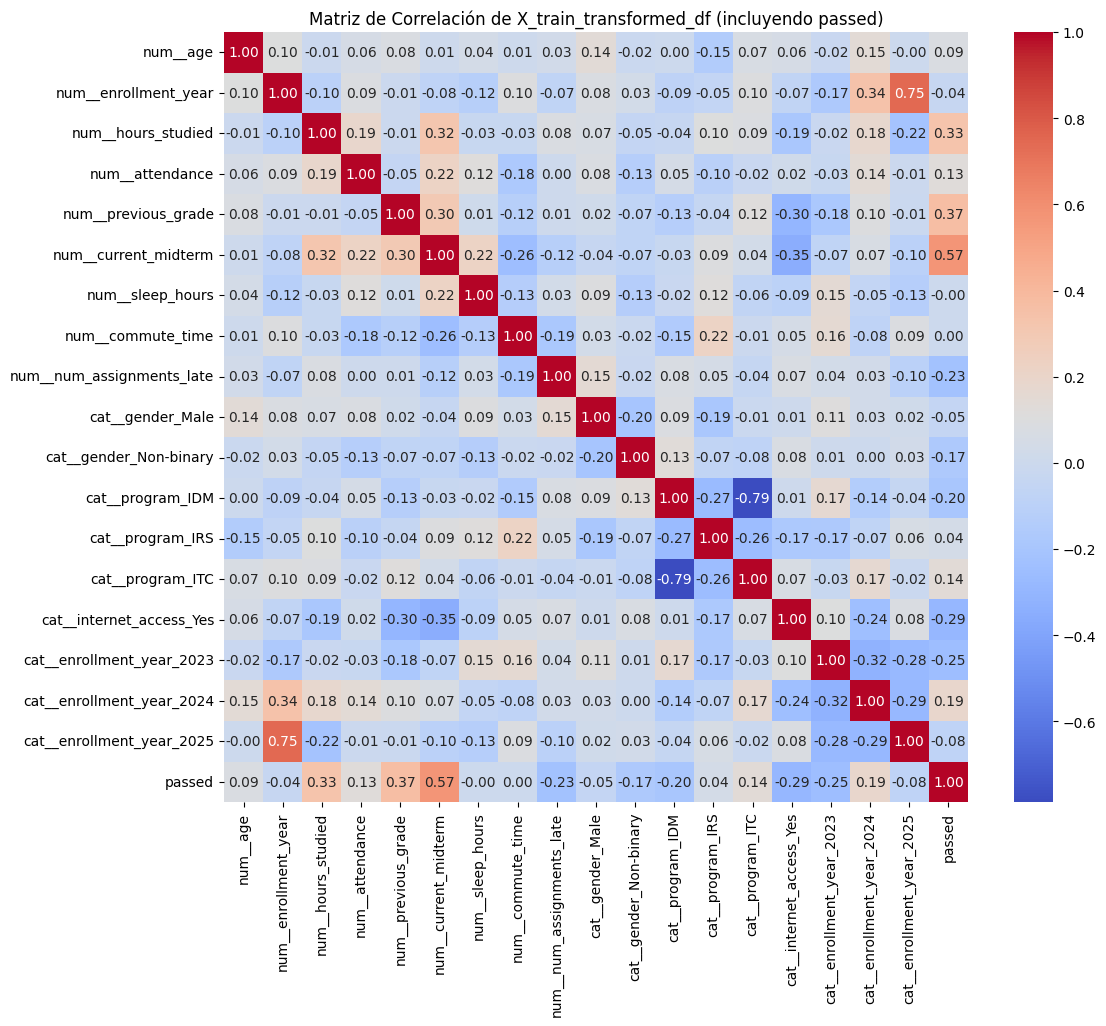

In [17]:
# Concatenar X_train_transformed_df con y_train para incluir 'passed' en la matriz de correlación
X_train_corr_df = pd.concat([X_train_transformed_df, y_train.reset_index(drop=True)], axis=1)

# Evaluar la matriz de correlación para los datos de entrenamiento transformados, incluyendo 'passed'
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de X_train_transformed_df (incluyendo passed)')
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

correlations = X_train_corr_df.corr()['passed'].sort_values(ascending=False)

top_4_features = correlations.drop('passed').head(4)

print (top_4_features)

num__current_midterm         0.573052
num__previous_grade          0.367015
num__hours_studied           0.331027
cat__enrollment_year_2024    0.185167
Name: passed, dtype: float64


### Selección y transformación de features

| Feature | Acción | Justificación |
|---|---|---|
| `student_id` | Remove | Es un identificador único y no proporciona información relevante para la predicción. |
| `age` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `gender` | Transform → Remove | Fue transformada mediante One-Hot Encoding, pero las variables resultantes presentaron una correlación poco relevante con passed. |
| `program` | Transform → Remove | Fue transformada mediante One-Hot Encoding, pero las variables resultantes presentaron una correlación poco relevante con passed. |
| `enrollment_year` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `hours_studied` | Transform → Keep | Fue estandarizada mediante StandardScaler y presentó una correlación relevante con la variable objetivo. |
| `attendance` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `previous_grade` | Transform → Keep | Fue estandarizada mediante StandardScaler y presentó una correlación relevante con la variable objetivo. |
| `current_midterm` | Transform → Keep | Fue estandarizada mediante StandardScaler y presentó una correlación relevante con la variable objetivo. |
| `sleep_hours` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `commute_time` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `num_assignments_late` | Transform → Remove | Fue estandarizada mediante StandardScaler, pero presentó una correlación poco relevante con la variable objetivo. |
| `internet_access` | Transform → Remove | Fue transformada mediante One-Hot Encoding, pero las variables resultantes presentaron una correlación poco relevante con passed. |
| `final_grade` | Transform → Keep | Fue estandarizada mediante StandardScaler y presentó la mayor correlación con la variable objetivo. |
| `passed` | Target Variable | Es la variable que el modelo busca predecir. |

### Train-test slipt
En esta sección entrenamos el modelos con las 4 variables seleccionadas

In [19]:
selected_features = top_4_features.index.tolist()

columns_to_drop = [
    col for col in X_train_transformed_df.columns
    if col not in selected_features
]

X_train_top4 = X_train_transformed_df.drop(
    columns=columns_to_drop
)

X_test_top4 = X_test_transformed_df.drop(
    columns=columns_to_drop
)


# Prediction Model (Regresión Logística)

Se utilizó la regresión logística para intentar predecir si el alumno pasó o no pasó.

In [20]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_top4, y_train)

y_pred = logistic_model.predict(X_test_top4)

### Evaluación del Modelo

In [21]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.86      0.75      0.80         8

    accuracy                           0.92        36
   macro avg       0.89      0.86      0.87        36
weighted avg       0.91      0.92      0.91        36



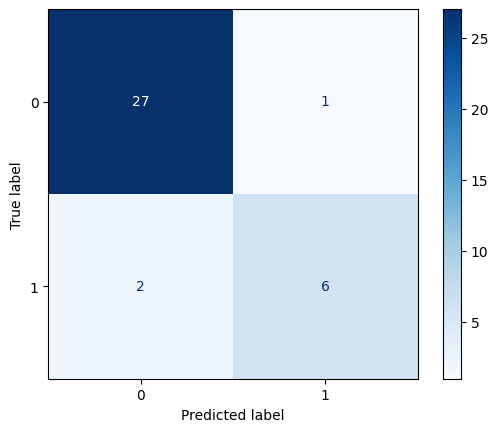

In [22]:
ConfusionMatrixDisplay.from_estimator(logistic_model, X_test_top4, y_test, cmap='Blues')
plt.show()